<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_07/avcad_ex07_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 7**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `How do I extract r-square and F-statistics from a statsmodels OLS fit?`
- `What's the cleanest way to make partial dependence plots from an OLS multiple regression?`
- `How do I compute and interpret VIF for multicollinearity in Python?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

Using the dataset in `EFIplus_medit.zip`:

1. Run a simple linear regression relating the species richness with each one of the continuous environmental variables in the dataset: Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul. Before running the analyses, check if any of the variables requires to be transformed and apply the appropriate transformation. Compute the regression coefficient estimates, the r-square and the F-statistics. You may plot the fitted model.
2. Now try to run a multiple linear regression with the same data and check the differences between the previous univariate regression coefficients and the new coefficients. Plot the partial dependence plots to compare responses with the previous single effects.
3. Check the multicollinearity among the predictor variables and run a second more parsimonious regression model. Check how the coefficients have changed.

## 1. Setup and Data Preparation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with NaN
df2 = df.dropna().copy()

# Build species richness from 'Abramis brama' onward
first_species_idx = df2.columns.get_loc('Abramis brama')
species_cols = list(df2.columns[first_species_idx:])
df2['species_richness'] = df2[species_cols].sum(axis=1)

print(f"Shape: {df2.shape}")
print(f"Species richness: mean = {df2['species_richness'].mean():.2f}, range = [{df2['species_richness'].min()}, {df2['species_richness'].max()}]")

Shape: (2822, 155)
Species richness: mean = 3.42, range = [0, 14]


In [3]:
# @title Global Plot Settings

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

### Data Transformation

From Exercise 6 we already know that **Altitude**, **Actual_river_slope**, and **prec_ann_catch** are right-skewed and benefit from a `log1p` transformation. The other four variables (`Elevation_mean_catch`, `temp_ann`, `temp_jan`, `temp_jul`) are approximately symmetric and are kept on their original scale.

In [4]:
# Apply log1p to skewed variables
for var in ['Altitude', 'Actual_river_slope', 'prec_ann_catch']:
    df2[f'{var}_log'] = np.log1p(df2[var])

predictors = ['Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch',
              'prec_ann_catch_log', 'temp_ann', 'temp_jan', 'temp_jul']

pd.DataFrame({
    'mean':  df2[predictors].mean().round(3),
    'std':   df2[predictors].std().round(3),
    'skew':  df2[predictors].skew().round(3),
})

,mean,std,skew
Altitude_log,5.296,1.275,-0.958
Actual_river_slope_log,2.275,1.018,0.012
Elevation_mean_catch,668.768,371.261,0.754
prec_ann_catch_log,6.945,0.259,-0.890
temp_ann,13.432,1.909,-0.213
temp_jan,7.044,2.441,-0.403
temp_jul,19.919,2.020,0.638


---
## 2. Q1: Simple linear regression — species richness vs each environmental variable

For each predictor we fit `species_richness ~ predictor` with OLS and report:
- the slope (β₁) and intercept (β₀)
- the coefficient of determination (R²)
- the F-statistic and its p-value

In [5]:
y = df2['species_richness']

uni_results = []
uni_models = {}
for var in predictors:
    X = sm.add_constant(df2[[var]])
    model = sm.OLS(y, X).fit()
    uni_models[var] = model
    uni_results.append({
        'variable':  var,
        'intercept': round(model.params['const'], 4),
        'slope':     round(model.params[var], 4),
        'r_squared': round(model.rsquared, 4),
        'F-stat':    round(model.fvalue, 2),
        'p-value':   model.f_pvalue,
    })

uni_df = pd.DataFrame(uni_results).set_index('variable')
uni_df

,intercept,slope,r_squared,F-stat,p-value
variable,,,,,
Altitude_log,7.4449,-0.7603,0.1588,532.46,4.611434e-108
Actual_river_slope_log,5.7990,-1.0465,0.1919,669.61,1.173973e-132
Elevation_mean_catch,4.7398,-0.0020,0.0909,282.13,2.025638e-60
prec_ann_catch_log,22.4507,-2.7404,0.0852,262.79,1.415693e-56
temp_ann,-5.6824,0.6775,0.2826,1110.65,1.282194e-205
temp_jan,0.9156,0.3553,0.1271,410.49,2.545736e-85
temp_jul,-10.4399,0.6957,0.3337,1412.25,6.315777e-251


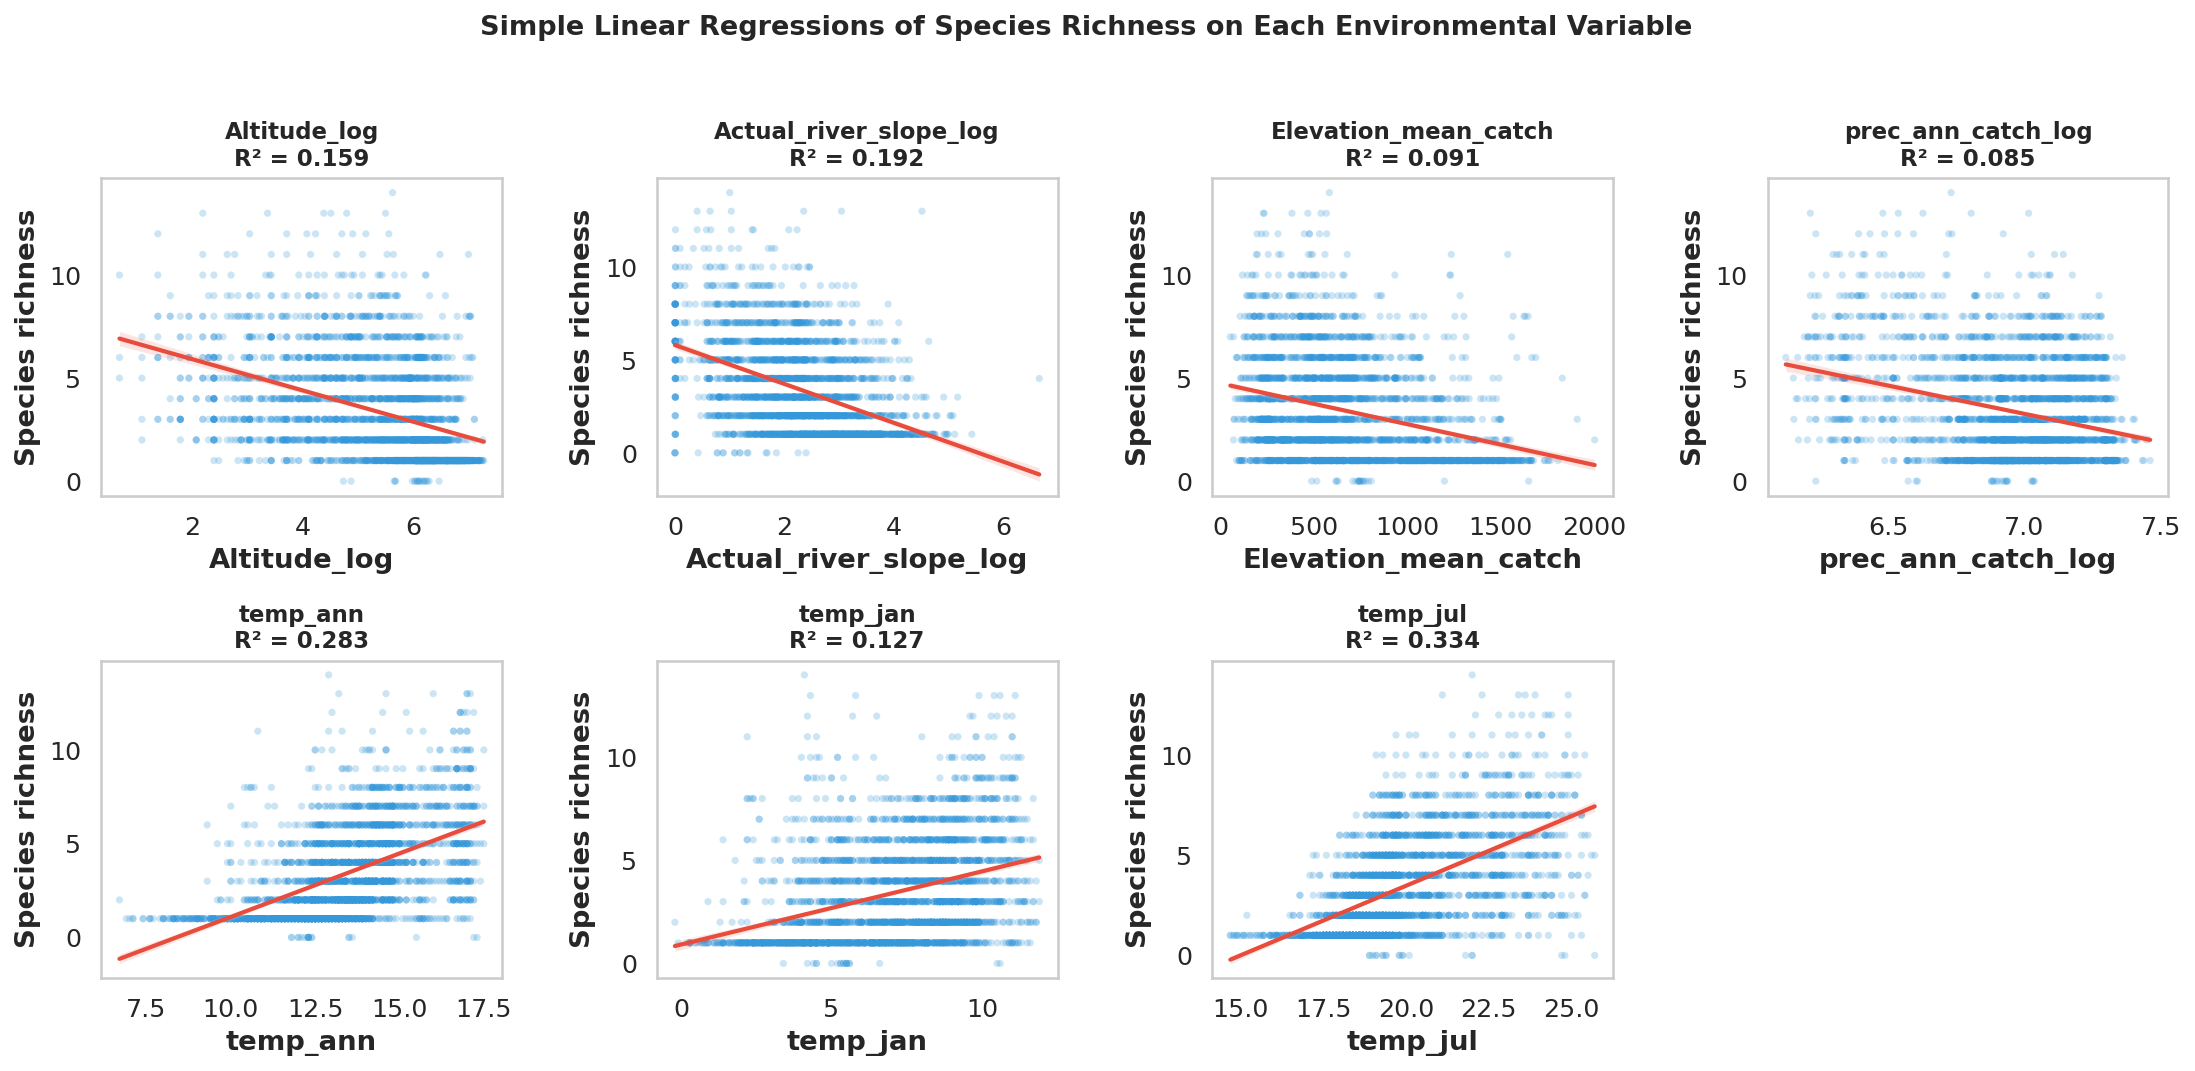

In [6]:
# @title Plot fitted simple regressions

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, var in enumerate(predictors):
    sns.regplot(x=df2[var], y=y, ax=axes[i],
                scatter_kws={'alpha': 0.25, 's': 12, 'color': '#3498db', 'edgecolor': 'none'},
                line_kws={'color': '#e74c3c', 'linewidth': 2})
    r2 = uni_models[var].rsquared
    axes[i].set_title(f"{var}\nR² = {r2:.3f}", fontsize=11)
    axes[i].set_ylabel("Species richness")
    axes[i].grid(False)

axes[-1].axis('off')
fig.suptitle("Simple Linear Regressions of Species Richness on Each Environmental Variable",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

All seven simple regressions are highly significant (very small p-values from the F-test), thanks to the large sample size, but the **R² values are modest** — no single environmental variable explains more than about a third of the variance in species richness. The strongest single predictors are the summer and annual temperatures (`temp_jul`, R² = 0.33; `temp_ann`, R² = 0.28), followed by `Actual_river_slope_log` (0.19) and `Altitude_log` (0.16). `Elevation_mean_catch` and `prec_ann_catch_log` are the weakest (R² < 0.10). This is consistent with temperature being the dominant environmental gradient for Mediterranean fish communities.

---
## 3. Q2: Multiple linear regression with all predictors

We now fit a single model with all seven environmental variables together: `species_richness ~ Altitude_log + Actual_river_slope_log + Elevation_mean_catch + prec_ann_catch_log + temp_ann + temp_jan + temp_jul`.

In [7]:
X_full = sm.add_constant(df2[predictors])
full_model = sm.OLS(y, X_full).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.435
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     309.7
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:16:03   Log-Likelihood:                -5706.9
No. Observations:                2822   AIC:                         1.143e+04
Df Residuals:                    2814   BIC:                         1.148e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -7

In [8]:
# @title Compare univariate vs multivariate coefficients

compare = pd.DataFrame({
    'univariate_slope':   [uni_models[v].params[v] for v in predictors],
    'multivariate_slope': [full_model.params[v] for v in predictors],
}, index=predictors).round(4)
compare['change'] = (compare['multivariate_slope'] - compare['univariate_slope']).round(4)
compare

,univariate_slope,multivariate_slope,change
Altitude_log,-0.7603,-0.6926,0.0677
Actual_river_slope_log,-1.0465,-0.4622,0.5843
Elevation_mean_catch,-0.0020,-0.0000,0.0020
prec_ann_catch_log,-2.7404,0.5981,3.3385
temp_ann,0.6775,0.3690,-0.3085
temp_jan,0.3553,-0.4454,-0.8007
temp_jul,0.6957,0.4750,-0.2207


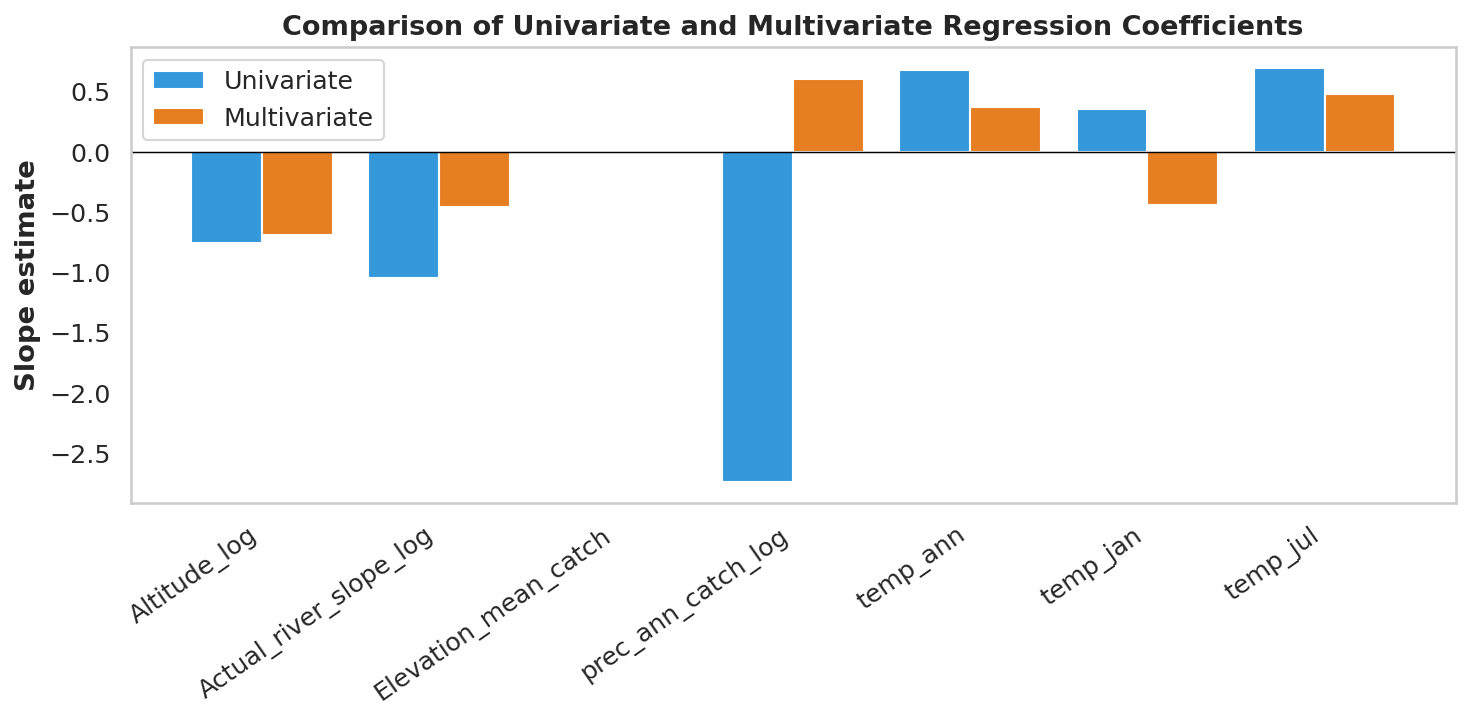

In [9]:
# @title Bar comparison of coefficients

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(predictors))
w = 0.4

ax.bar(x - w/2, compare['univariate_slope'],   width=w, color='#3498db', label='Univariate')
ax.bar(x + w/2, compare['multivariate_slope'], width=w, color='#e67e22', label='Multivariate')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(predictors, rotation=35, ha='right')
ax.set_ylabel("Slope estimate")
ax.set_title("Comparison of Univariate and Multivariate Regression Coefficients",
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

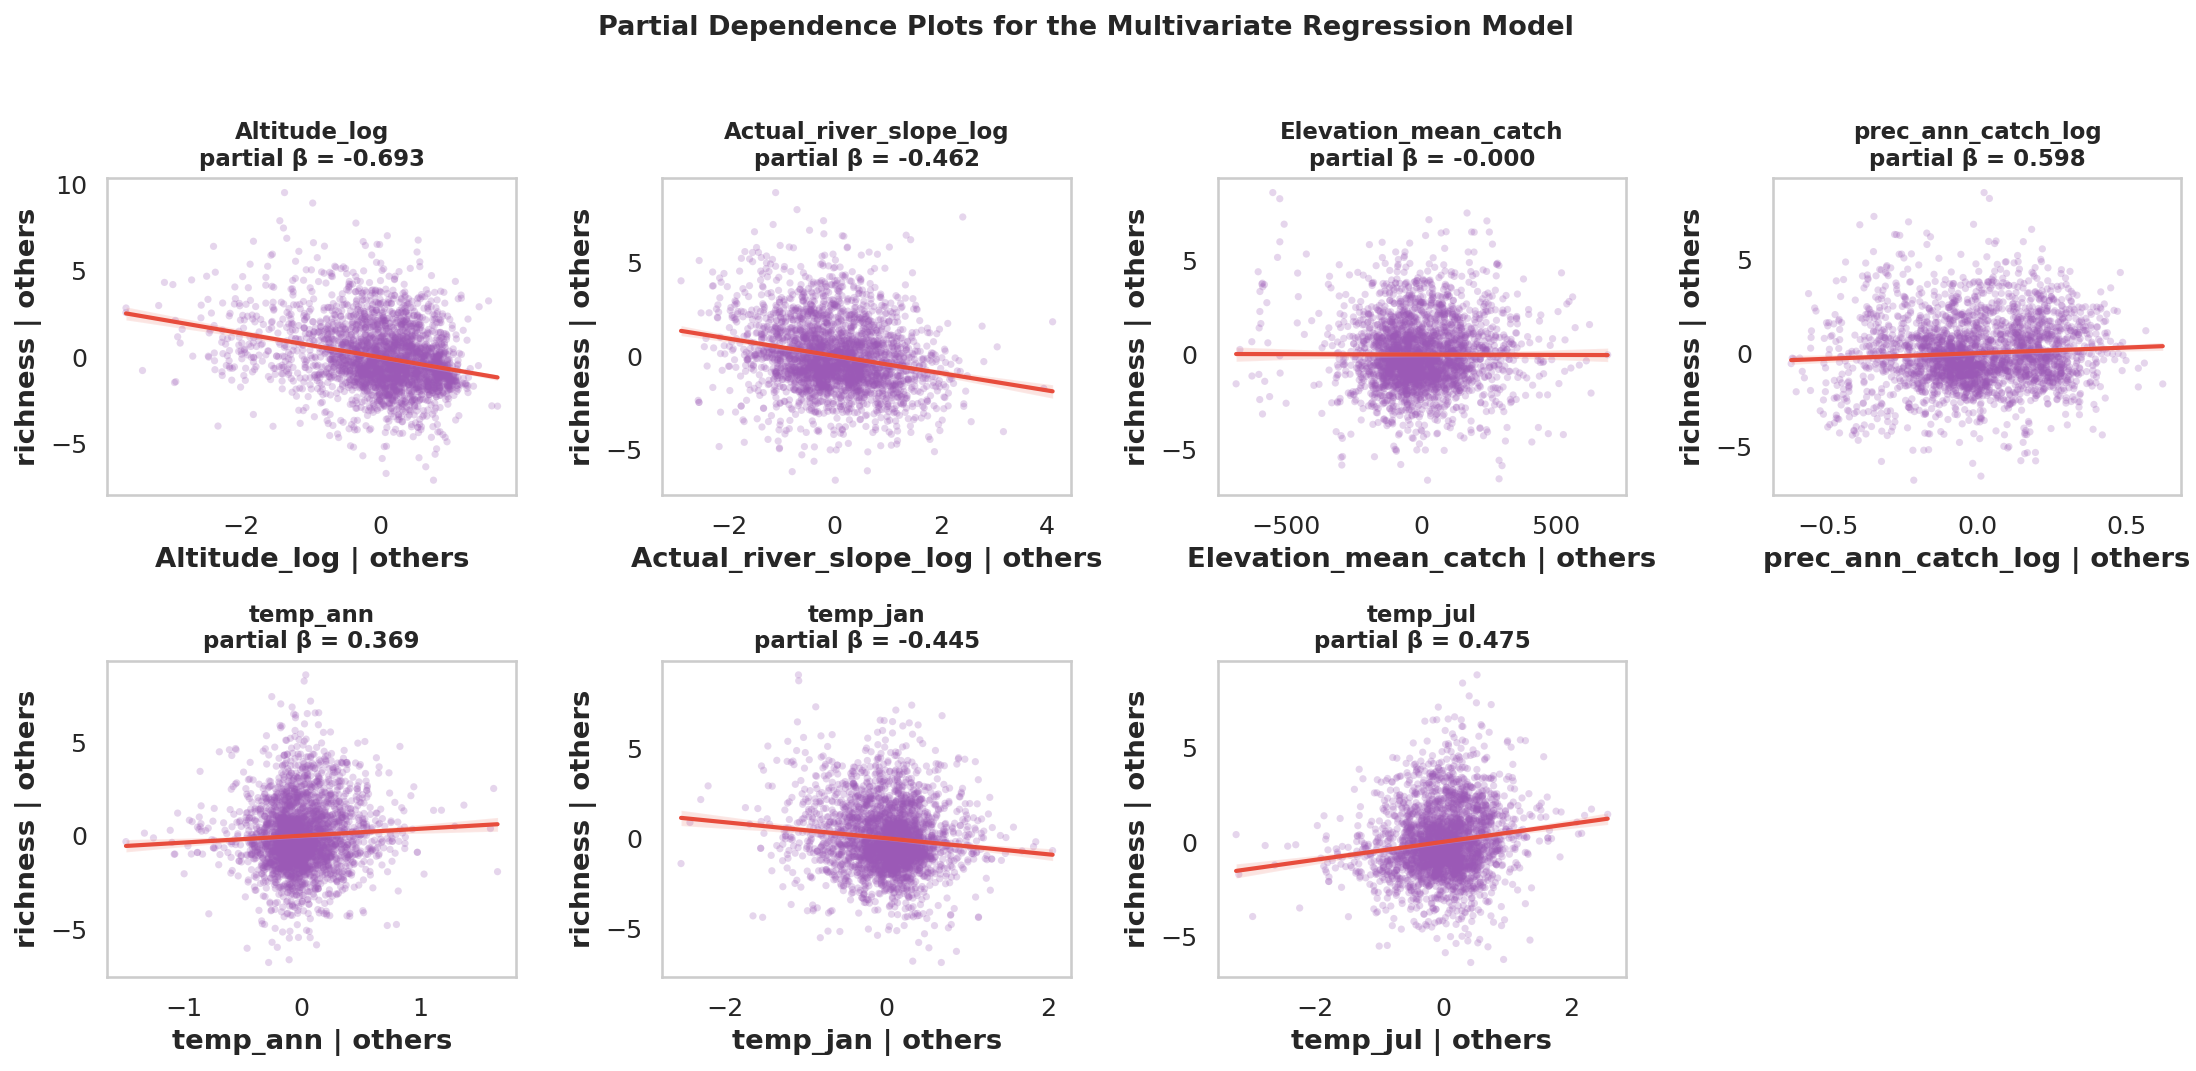

In [10]:
# @title Partial dependence (added-variable) plots

# We approximate partial dependence by plotting each predictor against the
# residuals of y regressed on all OTHER predictors, with the multivariate fit overlay.

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, var in enumerate(predictors):
    others = [v for v in predictors if v != var]
    # Residuals of y on all other predictors
    Xo = sm.add_constant(df2[others])
    res_y = sm.OLS(y, Xo).fit().resid
    # Residuals of var on all other predictors
    res_x = sm.OLS(df2[var], Xo).fit().resid

    sns.regplot(x=res_x, y=res_y, ax=axes[i],
                scatter_kws={'alpha': 0.25, 's': 12, 'color': '#9b59b6', 'edgecolor': 'none'},
                line_kws={'color': '#e74c3c', 'linewidth': 2})
    axes[i].set_title(f"{var}\npartial β = {full_model.params[var]:.3f}", fontsize=11)
    axes[i].set_xlabel(f"{var} | others")
    axes[i].set_ylabel("richness | others")
    axes[i].grid(False)

axes[-1].axis('off')
fig.suptitle("Partial Dependence Plots for the Multivariate Regression Model",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Several coefficients have **changed sign or magnitude** between the univariate and multivariate models. The clearest example is `temp_jan`, whose slope flips from positive (+0.36 alone) to negative (−0.45 in the full model); `prec_ann_catch_log` also flips sign, and `temp_ann`/`temp_jul` shrink substantially. This is a classic symptom of **multicollinearity**: because the temperature variables are intercorrelated (and also correlated with elevation), the regression cannot attribute the shared effect cleanly to any one of them. The partial dependence plots confirm this — the partial slopes are much weaker than the original univariate slopes for the correlated predictors.

---
## 4. Q3: Multicollinearity diagnosis and a parsimonious model

We diagnose multicollinearity with two complementary tools:
- **Pearson correlation matrix** of the predictors — for pairwise relationships
- **Variance Inflation Factor (VIF)** — quantifies how much the variance of each coefficient is inflated by the other predictors. A common rule of thumb is VIF > 5 (some authors use 10) → problematic collinearity.

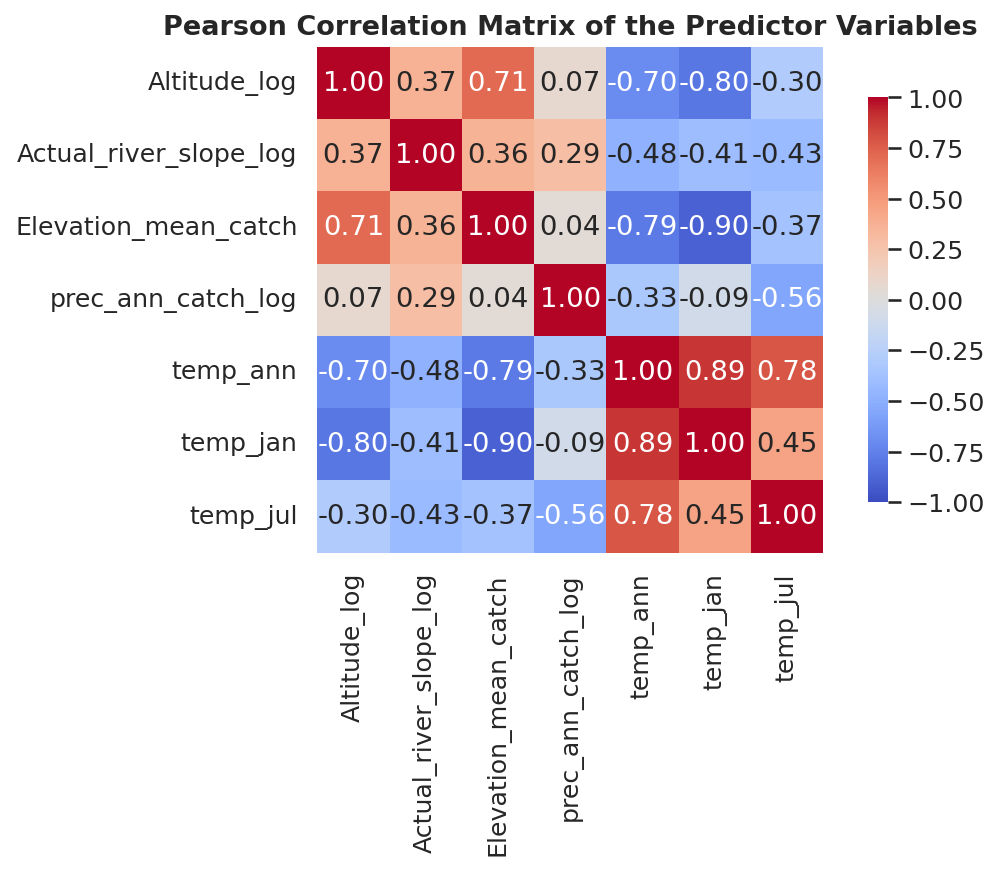

In [11]:
# @title Correlation matrix

corr = df2[predictors].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title("Pearson Correlation Matrix of the Predictor Variables",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# @title VIF for the full model

# NOTE: variance_inflation_factor requires a constant (intercept) column,
# otherwise the VIFs are massively inflated for variables with non-zero means.
X_vif = sm.add_constant(df2[predictors]).values
vif_full = pd.DataFrame({
    'variable': predictors,
    'VIF': [variance_inflation_factor(X_vif, i + 1)  # +1 skips the constant column
            for i in range(len(predictors))]
}).round(2).set_index('variable')
vif_full

,VIF
variable,
Altitude_log,2.99
Actual_river_slope_log,1.37
Elevation_mean_catch,5.54
prec_ann_catch_log,1.56
temp_ann,46.48
temp_jan,26.87
temp_jul,13.06


The correlation heatmap shows that the temperature variables are correlated, though not uniformly: `temp_ann` is strongly correlated with `temp_jan` (0.89) and `temp_jul` (0.78), but `temp_jan` and `temp_jul` are only moderately correlated with each other (0.45). The temperatures are also strongly **negatively** correlated with elevation — in fact the single strongest relationship in the matrix is `temp_jan` vs `Elevation_mean_catch` (−0.90).

The VIFs confirm that the three **temperature variables** are the source of the multicollinearity (high VIFs, well above the 5–10 threshold), while the remaining predictors (`Altitude_log`, `Actual_river_slope_log`, `Elevation_mean_catch`, `prec_ann_catch_log`) are at acceptable levels. Note that `temp_ann` has the highest VIF of all: because it behaves almost like a linear combination of the other temperatures *and* elevation, its variance is the most inflated even though no single pairwise correlation reaches 0.9.

**Reduction strategy:** keep `temp_ann` as the temperature representative (it summarizes the annual climate) and drop the redundant `temp_jan` and `temp_jul`. We keep the other predictors as they are.

In [13]:
# @title Parsimonious model

predictors_pars = ['Altitude_log', 'Actual_river_slope_log', 'Elevation_mean_catch',
                   'prec_ann_catch_log', 'temp_ann']

X_pars = sm.add_constant(df2[predictors_pars])
pars_model = sm.OLS(y, X_pars).fit()
print(pars_model.summary())

                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     330.8
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          2.38e-279
Time:                        23:16:10   Log-Likelihood:                -5860.8
No. Observations:                2822   AIC:                         1.173e+04
Df Residuals:                    2816   BIC:                         1.177e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2

In [14]:
# @title VIF for the parsimonious model

X_vif_p = sm.add_constant(df2[predictors_pars]).values
vif_pars = pd.DataFrame({
    'variable': predictors_pars,
    'VIF': [variance_inflation_factor(X_vif_p, i + 1)  # +1 skips the constant column
            for i in range(len(predictors_pars))]
}).round(2).set_index('variable')
vif_pars

,VIF
variable,
Altitude_log,2.32
Actual_river_slope_log,1.35
Elevation_mean_catch,3.36
prec_ann_catch_log,1.35
temp_ann,4.01


In [15]:
# @title Compare coefficients — full vs parsimonious vs univariate

compare2 = pd.DataFrame({
    'univariate':   [uni_models[v].params[v] if v in uni_models else np.nan for v in predictors_pars],
    'multivariate': [full_model.params[v] for v in predictors_pars],
    'parsimonious': [pars_model.params[v] for v in predictors_pars],
}, index=predictors_pars).round(4)
compare2

,univariate,multivariate,parsimonious
Altitude_log,-0.7603,-0.6926,-0.2977
Actual_river_slope_log,-1.0465,-0.4622,-0.5093
Elevation_mean_catch,-0.0020,-0.0000,0.0022
prec_ann_catch_log,-2.7404,0.5981,-0.4360
temp_ann,0.6775,0.3690,0.7248


In [16]:
# @title Fit summary comparison

fit_compare = pd.DataFrame({
    'n_predictors': [len(predictors), len(predictors_pars)],
    'r_squared':    [round(full_model.rsquared,    4), round(pars_model.rsquared,    4)],
    'adj_r_squared':[round(full_model.rsquared_adj,4), round(pars_model.rsquared_adj,4)],
    'F-statistic':  [round(full_model.fvalue,      2), round(pars_model.fvalue,      2)],
    'AIC':          [round(full_model.aic,         1), round(pars_model.aic,         1)],
    'BIC':          [round(full_model.bic,         1), round(pars_model.bic,         1)],
}, index=['full_model', 'parsimonious_model'])
fit_compare

,n_predictors,r_squared,adj_r_squared,F-statistic,AIC,BIC
full_model,7,0.4351,0.4337,309.69,11429.8,11477.3
parsimonious_model,5,0.3700,0.3689,330.84,11733.6,11769.2


After dropping `temp_jan` and `temp_jul`, the VIFs of the remaining predictors fall to acceptable levels (all below ~5.5) and the coefficients become **more stable and interpretable**. There is a trade-off, however: the R² decreases from 0.435 to 0.370 and both the AIC and BIC are slightly *higher* for the parsimonious model, so by pure goodness-of-fit criteria the full model still scores better. The two dropped temperature variables therefore did carry some non-redundant signal.

The value of the parsimonious model is not a better fit but **interpretability and coefficient stability**. The most telling result is the slope of `temp_ann`: it is 0.68 on its own (univariate), collapses to 0.37 in the full model — distorted by the collinear temperatures — and recovers to 0.72 in the parsimonious model, almost exactly its univariate value. Once the redundant temperatures are removed, the regression can attribute the temperature effect to a single, reliable coefficient instead of splitting and inflating it across three correlated terms. This is the usual reason to prefer a parsimonious model: a small, deliberate sacrifice in fit in exchange for coefficients that can actually be trusted and interpreted.